In [1]:
!nvidia-smi

Mon Jul  1 15:06:33 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.01             Driver Version: 535.183.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090        Off | 00000000:01:00.0 Off |                  N/A |
| 30%   50C    P8              25W / 370W |      1MiB / 24576MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
#!pip install matplotlib
#!pip install einops --user 
#!pip install torch==1.11.0+cu113 torchvision==0.12.0+cu113 torchaudio==0.11.0 --extra-index-url https://download.pytorch.org/whl/cu113 --user

In [3]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
#%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.utils
from   torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms
#from torchsummary import summary



In [4]:
# Model
#!pip install timm --user
#!pip install einops


In [5]:
from myNet3 import my_Network as myModel
#from MedViT2 import MedViT_Net as myModel

model = myModel()
#print("model.proj_head[0] : ",model.proj_head[0])
#print("model.proj_head : ",model.proj_head)
#model.proj_head[0] = torch.nn.Linear(in_features=1024, out_features=4, bias=True)
model = model.cuda()


initialize_weights...


In [6]:
print(model)

my_Net(
  (stem): Sequential(
    (0): ConvBNReLU(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
    )
  )
  (features): Sequential(
    (0): ConvSA(
      (patch_embed): PatchEmbed(
        (avgpool): AvgPool2d(kernel_size=(2, 2), stride=2, padding=0)
        (conv): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (norm1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (e_mhsa): E_MHSA(
        (q): Linear(in_features=128, out_features=128, bias=True)
        (k): Linear(in_features=128, out_features=128, bias=True)
        (v): Linear(in_features=128, out_features=128, bias=True)
        (proj): Linear(in_features=128, out_features=128, bias=True)
     

In [7]:
#!pip install gputil --user

In [8]:
#!pip install torchsummary --user --ignore-installed
#!pip install torchview --user --ignore-installed
#!pip install graphviz --user --ignore-installed
#!pip install scikit-learn --user --ignore-installed
#!brew install graphviz --user --ignore-installed

#from sklearn.tree import export_graphviz

#Make and fit model

#tree_file = export_graphviz(model, out_file=None)#,feature_names=X.columns)


#graphviz.Source(tree_file)

In [9]:
#import torchviz
#import cupy
#from torchviz import make_dot

# Assuming you already have a PyTorch model named 'model'
# and input_size is (1, 3, 224, 224)
#input_size = (1, 3, 224, 224)

# Create a dummy input tensor
#dummy_input = torch.randn(*input_size)
#dummy_input = cupy.array(dummy_input)
# Generate the computation graph
#graph = make_dot(model(dummy_input), params=dict(model.named_parameters()))

# Save the graph as a PNG file
#graph.render("model_graph", format="png")

In [10]:
from torchsummary import summary
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           1,728
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
        ConvBNReLU-4         [-1, 64, 112, 112]               0
         AvgPool2d-5           [-1, 64, 56, 56]               0
            Conv2d-6          [-1, 128, 56, 56]           8,192
       BatchNorm2d-7          [-1, 128, 56, 56]             256
        PatchEmbed-8          [-1, 128, 56, 56]               0
            Linear-9            [-1, 3136, 128]          16,512
        AvgPool1d-10             [-1, 128, 784]               0
      BatchNorm1d-11             [-1, 128, 784]             256
           Linear-12             [-1, 784, 128]          16,512
           Linear-13             [-1, 784, 128]          16,512
          Dropout-14         [-1, 8, 31

In [11]:
#from torchview import draw_graph
#model_graph = draw_graph(model, input_size=(1,3,224,224), expand_nested=True)
#model_graph.visual_graph



In [12]:
# Dataset
#!pip install medmnist
# !pip install augmix

from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as Subset
import torchvision.transforms as transforms

In [13]:
import GPUtil
GPUtil.showUtilization()

| ID | GPU | MEM |
------------------
|  0 |  2% |  4% |


# Loading data


In [14]:
NUM_EPOCHS = 1000
BATCH_SIZE = 16
lr = 0.001

import torchvision.datasets as datasets
from torchvision.transforms.transforms import Resize

In [15]:
# preprocessing
train_transform = transforms.Compose([
    transforms.Resize([224,224]),
    transforms.Lambda(lambda image: image.convert('RGB')),
    #transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    #transforms.GaussianBlur(11, sigma=(0.1, 2.0)),
    #torchvision.transforms.AugMix(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])
test_transform = transforms.Compose([
    transforms.Resize([224,224]),
    transforms.Lambda(lambda image: image.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])


In [16]:

#TrainPath = 'dataset/224/Training'
#TestPath  = 'dataset/224/Testing'

#TrainPath = 'dataset/224 cropped/Training'
#TestPath  = 'dataset/224 cropped/Testing'

TrainPath = 'FigshareDataset/train'
TestPath  = 'FigshareDataset/test'


# Update the path to your training set in Google Drive
#dataset_path = '/content/drive/My Drive/Dataset/Brain tumor datasets/archive/Training'
# Use the dataset_path when creating your custom dataset
full_train_dataset = datasets.ImageFolder(root=TrainPath, transform=train_transform)
# Create a data loader for your custom dataset

train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
#train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Update the path to your test set in Google Drive
#dataset_path = '/content/drive/My Drive/Dataset/Brain tumor datasets/archive/Testing'
# Use the dataset_path when creating your custom dataset
test_dataset = datasets.ImageFolder(root=TestPath, transform=test_transform)
# Create a data loader for your custom dataset
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)#, num_workers=4)

print(train_dataset)
print("===================")
print(test_dataset)
print("===================")


Dataset ImageFolder
    Number of datapoints: 460
    Root location: FigshareDataset/test
    StandardTransform
Transform: Compose(
               Resize(size=[224, 224], interpolation=bilinear, max_size=None, antialias=True)
               Lambda()
               ToTensor()
               Normalize(mean=[0.5], std=[0.5])
           )


## Training

In [17]:
# Training
# define loss function and optimizer
task = "multi-label"
if task == "multi-label, binary-class":
    criterion = nn.BCEWithLogitsLoss()
else:
    criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.8)

In [18]:
# train

#import pytorch_lightning
#from pytorch_lightning.callbacks.early_stopping import EarlyStopping

#early_stopping = EarlyStopping(monitor='val_loss', patience=5, mode='min')

def validate(model, val_dataloader, device='cuda'):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    num_samples = 0

    with torch.no_grad():
        for batch in val_dataloader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)  # Replace with your loss function

            total_loss += loss.item() * inputs.size(0)
            num_samples += inputs.size(0)

    val_loss = total_loss / num_samples
    return val_loss


#def early_stopping(train_loss, validation_loss, min_delta, tolerance):
#    counter = 0
#    if (validation_loss - train_loss) > min_delta:
#        counter +=1
#        print("Counter for early stopping = ",counter)
#        if counter >= tolerance:
#            return True

min_val_loss = 10
min_avg_val_loss = 10
counter = 0
cntr = 0
LR_Reduce_cnt = 0

Num_val_avg = 50
Val_Patience = 50
LR_Reduce_patience = 2
LR_Reduce_freq = 10
freq_cnt = 0

val_vector = [10]*(NUM_EPOCHS+Val_Patience)
trainingEpoch_loss = [1]*(NUM_EPOCHS)
validationEpoch_loss = [1]*(NUM_EPOCHS)
Avg_validationEpoch_loss = [1]*(NUM_EPOCHS)
min_validationEpoch_loss = [1]*(NUM_EPOCHS)
min_Avg_validationEpoch_loss = [1]*(NUM_EPOCHS)
LearningRate_Epoch = [1]*(NUM_EPOCHS)
for epoch in range(NUM_EPOCHS):
    freq_cnt += 1
    print('Epoch [%d/%d]'% (epoch+1, NUM_EPOCHS))
    model.train()
    c = 0
    L = 0
    for inputs, targets in tqdm(train_loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        # forward + backward + optimize
        optimizer.zero_grad()
        outputs = model(inputs)

        if task == 'multi-label, binary-class':
            targets = targets.to(torch.float32)
            loss = criterion(outputs, targets)
        else:
            targets = targets.squeeze().long()
            loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()
        c += 1
        L += loss

    loss = L/c
    #print('Loss = ', loss) 
    trainingEpoch_loss[epoch] = loss
    # Validate
    val_loss = validate(model, val_loader)  # Replace with your validation function
    validationEpoch_loss[epoch] = val_loss
    
    val_vector[epoch+Num_val_avg] = val_loss
    tmp_val = val_vector[epoch : epoch+Num_val_avg+1]
    #print("tmp val = ",tmp_val)

    avg_val_loss = np.mean(tmp_val)
    current_lr = scheduler.get_last_lr()[0]
    print("Train Loss= %1.4f,  Val Loss= %1.4f,  min Val Loss= %1.4f,  avg Val loss= %1.4f,  min avg val loss= %1.4f,  LR = %f" % (loss, val_loss, min_val_loss, avg_val_loss, min_avg_val_loss, current_lr)) 
    LearningRate_Epoch[epoch] = current_lr*1000
    Avg_validationEpoch_loss[epoch] = avg_val_loss
    min_validationEpoch_loss[epoch] = min_val_loss
    min_Avg_validationEpoch_loss[epoch] = min_avg_val_loss
    
    # early stopping
    if (val_loss <= min_val_loss): #& (counter >= 3) :
        min_val_loss = val_loss
        #counter = 0
        model3 = model
        Epoch_saved3 = epoch
        #LR_Reduce_cnt += 1
        #if LR_Reduce_cnt > LR_Reduce_patience:
            #LR_Reduce_cnt = 0
            #scheduler.step()
            #freq_cnt = 0
            #print("********************************* optimizer.lr reduced *********************************")
        
    if avg_val_loss <= min_avg_val_loss:
        min_avg_val_loss = avg_val_loss
        counter = 0
        LR_Reduce_cnt = 0
        model2 = model
        Epoch_saved = epoch
        print(f"1- Counter for early stopping = {counter},  LR_Reduce_counter = {LR_Reduce_cnt},  freq_cnt = {freq_cnt}")
    else:
        counter +=1
        print(f"2- Counter for early stopping = {counter},  LR_Reduce_counter = {LR_Reduce_cnt},  freq_cnt = {freq_cnt}")
        if (counter > Val_Patience) | (current_lr<0.000001):
            model = model2
            trainingEpoch_loss = trainingEpoch_loss[0:epoch]
            validationEpoch_loss = validationEpoch_loss[0:epoch]
            Avg_validationEpoch_loss = Avg_validationEpoch_loss[0:epoch]
            min_validationEpoch_loss = min_validationEpoch_loss[0:epoch]
            min_Avg_validationEpoch_loss = min_Avg_validationEpoch_loss[0:epoch]
            LearningRate_Epoch = LearningRate_Epoch[0:epoch]
            break
    if freq_cnt>= LR_Reduce_freq:
        freq_cnt = 0
        scheduler.step()
        
    GPUtil.showUtilization()


print(f"The model at epoch # {Epoch_saved} choosed as the final trained model.")


# # Save the trained model to a file
FileName = 'SavedModels/medvid_model_Figshare0540_lr_00001.pth'
torch.save(model.state_dict(), FileName)
print("Trained model is saved.")


Epoch [1/1000]


100%|██████████| 139/139 [00:09<00:00, 14.24it/s]


Train Loss= 0.7692,  Val Loss= 4.0550,  min Val Loss= 10.0000,  avg Val loss= 9.8834,  min avg val loss= 10.0000,  LR = 0.001000
1- Counter for early stopping = 0,  LR_Reduce_counter = 0,  freq_cnt = 1
| ID | GPU | MEM |
------------------
|  0 | 29% | 28% |
Epoch [2/1000]


100%|██████████| 139/139 [00:09<00:00, 15.43it/s]


Train Loss= 0.6455,  Val Loss= 4.2092,  min Val Loss= 4.0550,  avg Val loss= 9.7699,  min avg val loss= 9.8834,  LR = 0.001000
1- Counter for early stopping = 0,  LR_Reduce_counter = 0,  freq_cnt = 2
| ID | GPU | MEM |
------------------
|  0 | 28% | 28% |
Epoch [3/1000]


...

Train Loss= 0.0193,  Val Loss= 0.0225,  min Val Loss= 0.0152,  avg Val loss= 0.0306,  min avg val loss= 0.0278,  LR = 0.000002
2- Counter for early stopping = 49,  LR_Reduce_counter = 0,  freq_cnt = 3
| ID | GPU | MEM |
------------------
|  0 | 29% | 28% |
Epoch [274/1000]


100%|██████████| 139/139 [00:09<00:00, 14.48it/s]


Train Loss= 0.0155,  Val Loss= 0.0372,  min Val Loss= 0.0152,  avg Val loss= 0.0307,  min avg val loss= 0.0278,  LR = 0.000002
2- Counter for early stopping = 50,  LR_Reduce_counter = 0,  freq_cnt = 4
| ID | GPU | MEM |
------------------
|  0 | 34% | 28% |
Epoch [275/1000]


100%|██████████| 139/139 [00:09<00:00, 14.39it/s]


Train Loss= 0.0192,  Val Loss= 0.0470,  min Val Loss= 0.0152,  avg Val loss= 0.0311,  min avg val loss= 0.0278,  LR = 0.000002
2- Counter for early stopping = 51,  LR_Reduce_counter = 0,  freq_cnt = 5
The model at epoch # 223 choosed as the final trained model.
Trained model is saved.


In [19]:
            model = model2
            trainingEpoch_loss = trainingEpoch_loss[0:epoch]
            validationEpoch_loss = validationEpoch_loss[0:epoch]
            Avg_validationEpoch_loss = Avg_validationEpoch_loss[0:epoch]
            min_validationEpoch_loss = min_validationEpoch_loss[0:epoch]
            min_Avg_validationEpoch_loss = min_Avg_validationEpoch_loss[0:epoch]
            LearningRate_Epoch = LearningRate_Epoch[0:epoch]


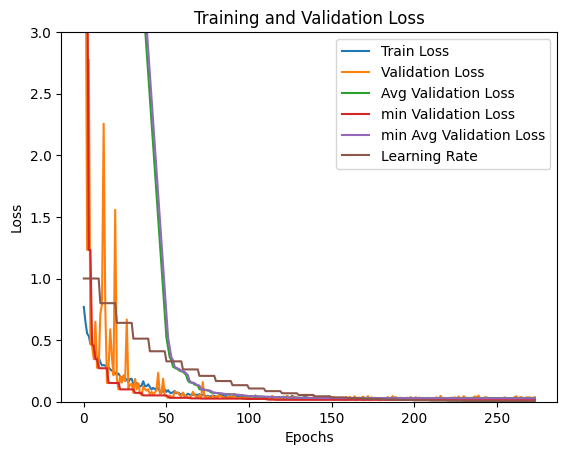

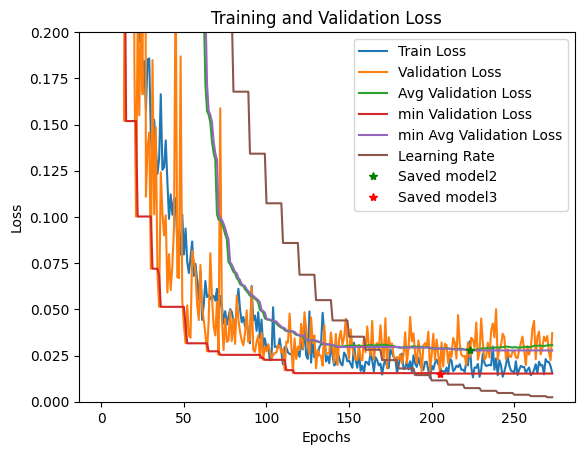

In [20]:
#!pip install scikit-learn
import matplotlib.pyplot as plt

trainingEpoch_loss2 = torch.tensor(trainingEpoch_loss, device = 'cpu')

# Assuming you have lists `trainingEpoch_loss` and `validationEpoch_loss`
plt.plot(trainingEpoch_loss2, label='Train Loss')
plt.plot(validationEpoch_loss, label='Validation Loss')
plt.plot(Avg_validationEpoch_loss, label='Avg Validation Loss')
plt.plot(min_validationEpoch_loss, label='min Validation Loss')
plt.plot(min_Avg_validationEpoch_loss, label='min Avg Validation Loss')
plt.plot(LearningRate_Epoch, label='Learning Rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.ylim(0, 3)
plt.show()

plt.plot(trainingEpoch_loss2, label='Train Loss')
plt.plot(validationEpoch_loss, label='Validation Loss')
plt.plot(Avg_validationEpoch_loss, label='Avg Validation Loss')
plt.plot(min_validationEpoch_loss, label='min Validation Loss')
plt.plot(min_Avg_validationEpoch_loss, label='min Avg Validation Loss')
plt.plot(LearningRate_Epoch, label='Learning Rate')
plt.plot(Epoch_saved,Avg_validationEpoch_loss[Epoch_saved], 'g*', label='Saved model2')
plt.plot(Epoch_saved3,validationEpoch_loss[Epoch_saved3], 'r*', label='Saved model3')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.ylim(0, 0.2)
plt.show()



# Evaluation


In [21]:


# pip install medmnist
# import medmnist
# from medmnist import INFO, Evaluator
# from medmnist.evaluator import getAUC, getACC
from sklearn.metrics import roc_auc_score
#Load the trained model

# loaded_model = tiny()  # Replace MedViDModelClass with the actual class name of your model
# loaded_model.proj_head[0]
# loaded_model.proj_head[0] = torch.nn.Linear(in_features=1024, out_features=4, bias=True)
# loaded_model.load_state_dict(torch.load(FileName))
# model = loaded_model;
# model = model.cuda()

#evaluation on test set

split = 'test'
model.eval()
y_true = torch.tensor([]).cuda()
y_score = torch.tensor([]).cuda()

data_loader = train_loader_at_eval if split == 'train' else test_loader
with torch.no_grad():
    for inputs, targets in data_loader:
        inputs, targets = inputs.cuda(), targets.cuda()
        outputs = model(inputs)

        if task == 'multi-label, binary-class':
            targets = targets.to(torch.float32)
            outputs = outputs.softmax(dim=-1)
        else:
            targets = targets.squeeze().long()
            outputs = outputs.softmax(dim=-1)
            targets = targets.float().resize_(len(targets), 1)

        y_true = torch.cat((y_true, targets), 0)
        y_score = torch.cat((y_score, outputs), 0)

    y_true = y_true.cpu().numpy()
    y_score = y_score.detach().cpu().numpy()
    #print('y_true 2: ',y_true)
    #print('y_score 2: ',y_score)

    recognized_classes = np.argmax(y_score, axis=1)
    recognized_classes = np.int16(recognized_classes)
    recognized_classes = recognized_classes.reshape(-1,1)
    y_true = np.int16(y_true)
    correct = (recognized_classes == y_true)
    nCorrect = correct.sum().item()
    total = len(y_true)
    accuracy = nCorrect / total*100
    print("Accuracy by using model with least average val loss : ", accuracy)




Accuracy by using model with least average val loss :  98.69565217391305


In [22]:
#import IPython.display as ipd

# Load an audio file (e.g., existing-file.wav)
#ipd.Audio('Dont-Go.mp3', autoplay=True)